# RF para datos fenotipicos y climaticos en PCA y heatmap

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

module_path = os.path.abspath(os.path.join("../../"))
if module_path not in sys.path:
    sys.path.append(module_path)

In [6]:
from machines.predictions.rf_prediction import RF_Prediction
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

## Carga de Archivo y preparar trainig and test

In [54]:
file_csv_original = {
    "phenotypic": "../../../data/phen/original/obregon_phenotypic_original_151617.csv",
    "phenotypic_weather_d": "../../../data/phen/original/phenotypic_weather_obregon_original_151617.csv",
    "phenotypic_weather_w": "../../../data/phen/original/phenotypic_weather_obregon_151617_seven.csv",
    "phenotypic_weather_f": "../../../data/phen/original/phenotypic_weather_obregon_151617_fifteen.csv",
    "phenotypic_weather_m": "../../../data/phen/original/phenotypic_weather_obregon_151617_thirty.csv",
}

file_csv_heatmap = {
    "phenotypic": "../../../data/phen/correlation/obregon_phenotypic_correlation_151617.csv",
    "phenotypic_weather_d": "../../../data/phen/correlation/phenotypic_weather_obregon_correlation_151617.csv",
    "phenotypic_weather_w": "../../../data/phen/correlation/phenotypic_weather_obregon_correlation_151617_seven.csv",
    "phenotypic_weather_f": "../../../data/phen/correlation/phenotypic_weather_obregon_correlation_151617_fifteen.csv",
    "phenotypic_weather_m": "../../../data/phen/correlation/phenotypic_weather_obregon_correlation_151617_thirty.csv",
}

## Original data

### Phenotypic

In [ ]:
file_csv = file_csv_original["phenotypic"]
title_plot_true_predict = "RF original phenotypic"

In [ ]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [ ]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [ ]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.64600519745614
R2 -> 0.8680812202887327
MAPE -> 0.03872169803677278


{'d2_absolute_error_score': 0.6832842506871926,
 'd2_pinball_score': 0.6832842506871926,
 'd2_tweedie_score': 0.8680812202887327,
 'explained_variance_score': 0.8695191082295821,
 'max_error': 218.37082209999994,
 'mean_absolute_error': 22.099635123648568,
 'mean_absolute_percentage_error': 0.03872169803677278,
 'mean_gamma_deviance': 0.003809207803856122,
 'mean_poisson_deviance': 2.14193761901998,
 'mean_squared_error': 1270.63768653707,
 'mean_squared_log_error': 0.004014692478412516,
 'median_absolute_error': 12.917075150000471,
 'r2_score': 0.8680812202887327,
 'root_mean_squared_error': 35.64600519745614,
 'root_mean_squared_log_error': 0.0633616009773468}

Graficas

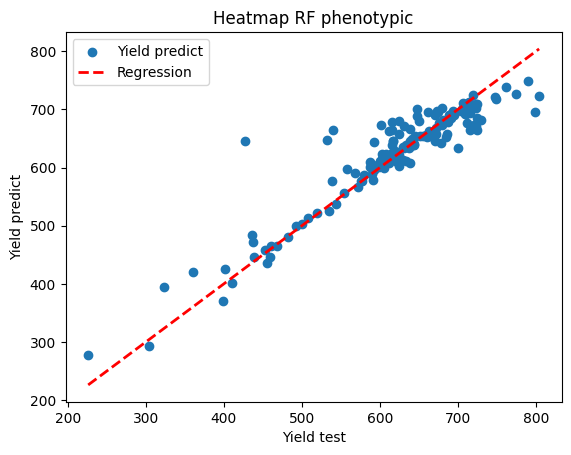

In [ ]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean daily

In [29]:
file_csv = file_csv_original["phenotypic_weather_d"]
title_plot_true_predict = "RF Original phenotypic weather daily"

In [30]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [31]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [32]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.60724319354866
R2 -> 0.8683679652416361
MAPE -> 0.0386047838720562


{'d2_absolute_error_score': 0.6842162954938178,
 'd2_pinball_score': 0.6842162954938178,
 'd2_tweedie_score': 0.8683679652416361,
 'explained_variance_score': 0.8697634892186787,
 'max_error': 219.57578769999998,
 'mean_absolute_error': 22.034599361486446,
 'mean_absolute_percentage_error': 0.0386047838720562,
 'mean_gamma_deviance': 0.003821870368673421,
 'mean_poisson_deviance': 2.1410625947717885,
 'mean_squared_error': 1267.8757678445174,
 'mean_squared_log_error': 0.004029731089215683,
 'median_absolute_error': 12.542697050000072,
 'r2_score': 0.8683679652416361,
 'root_mean_squared_error': 35.60724319354866,
 'root_mean_squared_log_error': 0.06348016295832647}

Graficas

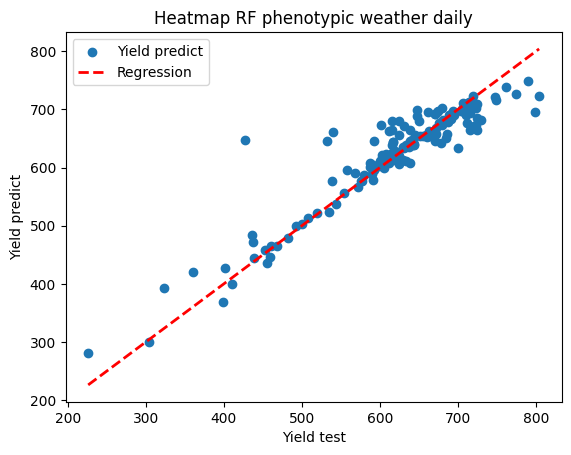

In [34]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean weekly

In [42]:
file_csv = file_csv_original["phenotypic_weather_w"]
title_plot_true_predict = "Heatmap RF phenotypic weather weekly"

In [36]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

/usr/local/lib/python3.12/site-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed values: [322]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Ejecutar la nueva ML

In [37]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [38]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.727294895101096
R2 -> 0.8674788602132151
MAPE -> 0.03810352670438258


{'d2_absolute_error_score': 0.6850783022318552,
 'd2_pinball_score': 0.6850783022318552,
 'd2_tweedie_score': 0.8674788602132151,
 'explained_variance_score': 0.8697097957817947,
 'max_error': 211.9322926000001,
 'mean_absolute_error': 21.974450681081102,
 'mean_absolute_percentage_error': 0.03810352670438258,
 'mean_gamma_deviance': 0.0035982609244871178,
 'mean_poisson_deviance': 2.101285233535312,
 'mean_squared_error': 1276.439600521517,
 'mean_squared_log_error': 0.003784253268779931,
 'median_absolute_error': 12.1227750500002,
 'r2_score': 0.8674788602132151,
 'root_mean_squared_error': 35.727294895101096,
 'root_mean_squared_log_error': 0.06151628458205137}

Graficas

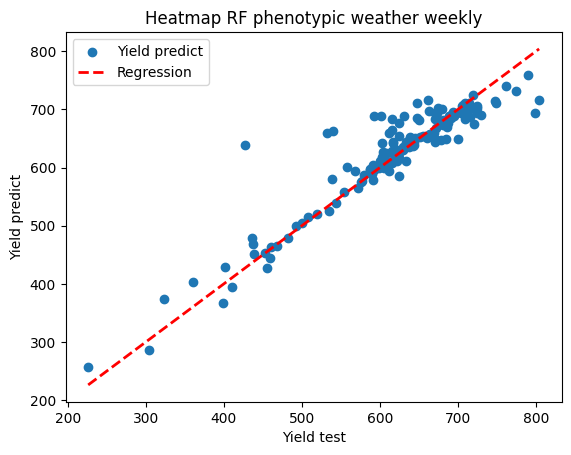

In [39]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean fortnightly

In [43]:
file_csv = file_csv_original["phenotypic_weather_f"]
title_plot_true_predict = "RF original phenotypic weather fortnightly"

In [44]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [45]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [46]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.70130663529879
R2 -> 0.8676715835206341
MAPE -> 0.038040177456780386


{'d2_absolute_error_score': 0.6854999226741043,
 'd2_pinball_score': 0.6854999226741043,
 'd2_tweedie_score': 0.8676715835206341,
 'explained_variance_score': 0.8699054125134567,
 'max_error': 213.21761060000006,
 'mean_absolute_error': 21.94503105810816,
 'mean_absolute_percentage_error': 0.038040177456780386,
 'mean_gamma_deviance': 0.003606059160158677,
 'mean_poisson_deviance': 2.1004798314117257,
 'mean_squared_error': 1274.5832954676293,
 'mean_squared_log_error': 0.0037953336666547493,
 'median_absolute_error': 12.083523799999739,
 'r2_score': 0.8676715835206341,
 'root_mean_squared_error': 35.70130663529879,
 'root_mean_squared_log_error': 0.061606279441748055}

Graficas

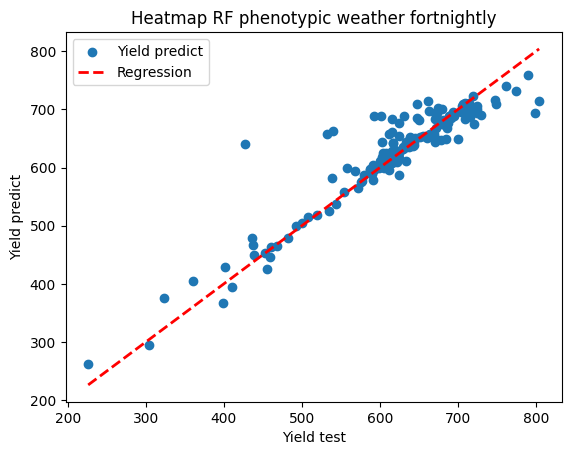

In [47]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean monthly

In [53]:
file_csv = file_csv_original["phenotypic_weather_m"]
title_plot_true_predict = "RF original phenotypic weather monthly"

In [49]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [50]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [51]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.840994490490175
R2 -> 0.866634039702426
MAPE -> 0.03821825471779673


{'d2_absolute_error_score': 0.6844688932657577,
 'd2_pinball_score': 0.6844688932657577,
 'd2_tweedie_score': 0.866634039702426,
 'explained_variance_score': 0.8688970747520302,
 'max_error': 213.44390420000002,
 'mean_absolute_error': 22.016973718918837,
 'mean_absolute_percentage_error': 0.03821825471779673,
 'mean_gamma_deviance': 0.00363973866517426,
 'mean_poisson_deviance': 2.117884920794772,
 'mean_squared_error': 1284.576886067347,
 'mean_squared_log_error': 0.003830581057914686,
 'median_absolute_error': 12.005018099999916,
 'r2_score': 0.866634039702426,
 'root_mean_squared_error': 35.840994490490175,
 'root_mean_squared_log_error': 0.06189168811653699}

Graficas

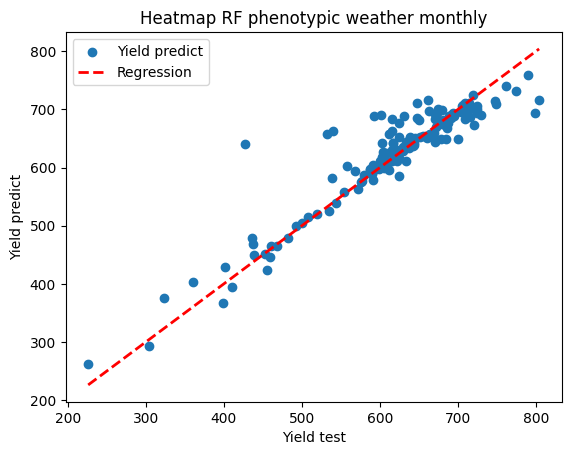

In [52]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

## Heatmap data

### Phenotypic

In [55]:
file_csv = file_csv_heatmap["phenotypic"]
title_plot_true_predict = "RF original phenotypic"

In [56]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

FileNotFoundError: [Errno 2] No such file or directory: '../../../data/phen/correlation/obregon_phenotypic_correlation_151617.csv'

Ejecutar la nueva ML

In [ ]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [ ]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.64600519745614
R2 -> 0.8680812202887327
MAPE -> 0.03872169803677278


{'d2_absolute_error_score': 0.6832842506871926,
 'd2_pinball_score': 0.6832842506871926,
 'd2_tweedie_score': 0.8680812202887327,
 'explained_variance_score': 0.8695191082295821,
 'max_error': 218.37082209999994,
 'mean_absolute_error': 22.099635123648568,
 'mean_absolute_percentage_error': 0.03872169803677278,
 'mean_gamma_deviance': 0.003809207803856122,
 'mean_poisson_deviance': 2.14193761901998,
 'mean_squared_error': 1270.63768653707,
 'mean_squared_log_error': 0.004014692478412516,
 'median_absolute_error': 12.917075150000471,
 'r2_score': 0.8680812202887327,
 'root_mean_squared_error': 35.64600519745614,
 'root_mean_squared_log_error': 0.0633616009773468}

Graficas

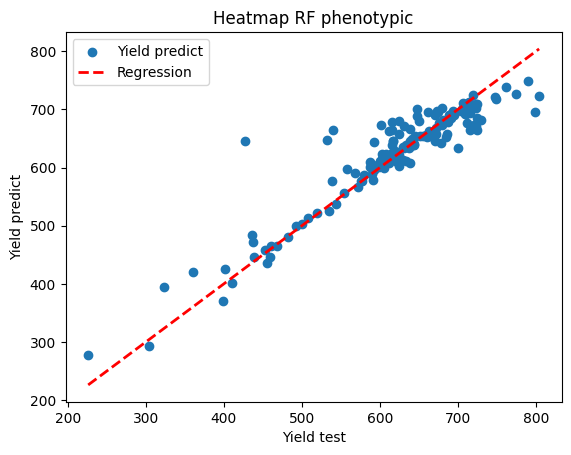

In [ ]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean daily

In [ ]:
file_csv = file_csv_original["phenotypic_weather_d"]
title_plot_true_predict = "RF Original phenotypic weather daily"

In [ ]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [ ]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [ ]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.60724319354866
R2 -> 0.8683679652416361
MAPE -> 0.0386047838720562


{'d2_absolute_error_score': 0.6842162954938178,
 'd2_pinball_score': 0.6842162954938178,
 'd2_tweedie_score': 0.8683679652416361,
 'explained_variance_score': 0.8697634892186787,
 'max_error': 219.57578769999998,
 'mean_absolute_error': 22.034599361486446,
 'mean_absolute_percentage_error': 0.0386047838720562,
 'mean_gamma_deviance': 0.003821870368673421,
 'mean_poisson_deviance': 2.1410625947717885,
 'mean_squared_error': 1267.8757678445174,
 'mean_squared_log_error': 0.004029731089215683,
 'median_absolute_error': 12.542697050000072,
 'r2_score': 0.8683679652416361,
 'root_mean_squared_error': 35.60724319354866,
 'root_mean_squared_log_error': 0.06348016295832647}

Graficas

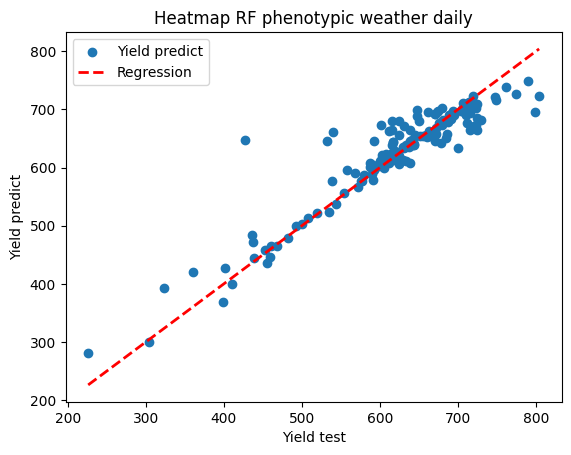

In [ ]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean weekly

In [ ]:
file_csv = file_csv_original["phenotypic_weather_w"]
title_plot_true_predict = "Heatmap RF phenotypic weather weekly"

In [ ]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

/usr/local/lib/python3.12/site-packages/sklearn/impute/_base.py:565: UserWarning: Skipping features without any observed values: [322]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Ejecutar la nueva ML

In [ ]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [ ]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.727294895101096
R2 -> 0.8674788602132151
MAPE -> 0.03810352670438258


{'d2_absolute_error_score': 0.6850783022318552,
 'd2_pinball_score': 0.6850783022318552,
 'd2_tweedie_score': 0.8674788602132151,
 'explained_variance_score': 0.8697097957817947,
 'max_error': 211.9322926000001,
 'mean_absolute_error': 21.974450681081102,
 'mean_absolute_percentage_error': 0.03810352670438258,
 'mean_gamma_deviance': 0.0035982609244871178,
 'mean_poisson_deviance': 2.101285233535312,
 'mean_squared_error': 1276.439600521517,
 'mean_squared_log_error': 0.003784253268779931,
 'median_absolute_error': 12.1227750500002,
 'r2_score': 0.8674788602132151,
 'root_mean_squared_error': 35.727294895101096,
 'root_mean_squared_log_error': 0.06151628458205137}

Graficas

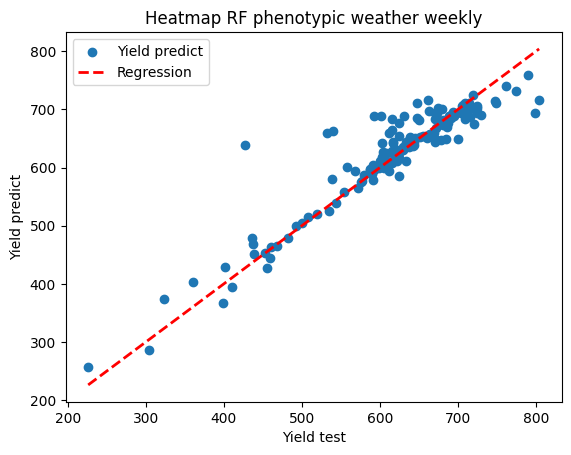

In [ ]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean fortnightly

In [ ]:
file_csv = file_csv_original["phenotypic_weather_f"]
title_plot_true_predict = "RF original phenotypic weather fortnightly"

In [ ]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [ ]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [ ]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.70130663529879
R2 -> 0.8676715835206341
MAPE -> 0.038040177456780386


{'d2_absolute_error_score': 0.6854999226741043,
 'd2_pinball_score': 0.6854999226741043,
 'd2_tweedie_score': 0.8676715835206341,
 'explained_variance_score': 0.8699054125134567,
 'max_error': 213.21761060000006,
 'mean_absolute_error': 21.94503105810816,
 'mean_absolute_percentage_error': 0.038040177456780386,
 'mean_gamma_deviance': 0.003606059160158677,
 'mean_poisson_deviance': 2.1004798314117257,
 'mean_squared_error': 1274.5832954676293,
 'mean_squared_log_error': 0.0037953336666547493,
 'median_absolute_error': 12.083523799999739,
 'r2_score': 0.8676715835206341,
 'root_mean_squared_error': 35.70130663529879,
 'root_mean_squared_log_error': 0.061606279441748055}

Graficas

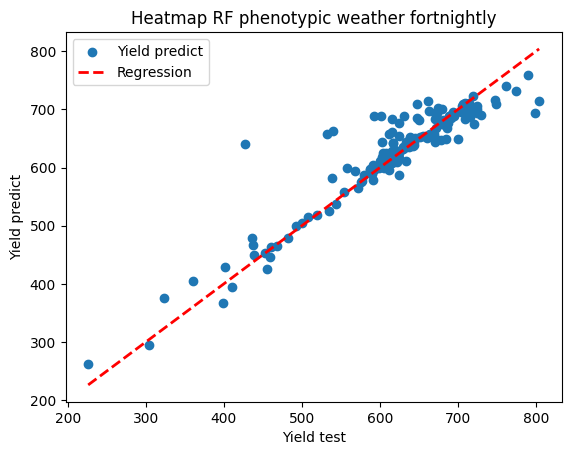

In [ ]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)

### Phenotypic and weather mean monthly

In [ ]:
file_csv = file_csv_original["phenotypic_weather_m"]
title_plot_true_predict = "RF original phenotypic weather monthly"

In [ ]:
preprocessing = Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.MEAN,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

x_train, y_train = preprocessing.get_train()
x_test, y_test = preprocessing.get_test()

Ejecutar la nueva ML

In [ ]:
rf = RF_Prediction()
rf.training(x_train=x_train, y_train=y_train)
y_predicted = rf.prediction(x_test=x_test)

Obtener todas las metricas

In [ ]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 35.840994490490175
R2 -> 0.866634039702426
MAPE -> 0.03821825471779673


{'d2_absolute_error_score': 0.6844688932657577,
 'd2_pinball_score': 0.6844688932657577,
 'd2_tweedie_score': 0.866634039702426,
 'explained_variance_score': 0.8688970747520302,
 'max_error': 213.44390420000002,
 'mean_absolute_error': 22.016973718918837,
 'mean_absolute_percentage_error': 0.03821825471779673,
 'mean_gamma_deviance': 0.00363973866517426,
 'mean_poisson_deviance': 2.117884920794772,
 'mean_squared_error': 1284.576886067347,
 'mean_squared_log_error': 0.003830581057914686,
 'median_absolute_error': 12.005018099999916,
 'r2_score': 0.866634039702426,
 'root_mean_squared_error': 35.840994490490175,
 'root_mean_squared_log_error': 0.06189168811653699}

Graficas

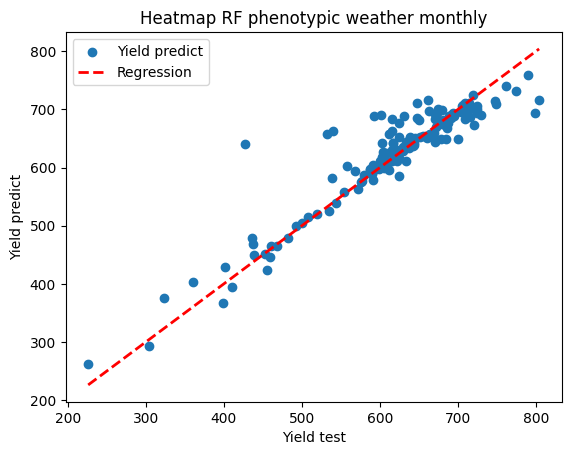

In [ ]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = title_plot_true_predict
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)